# =============================================================================
# Mini-Projet : Régularisation des Modèles de Machine Learning
# Réduire la marge de performance entre les données d'entraînement et de test
# Université Sultan Moulay Slimane - Faculté Polydisciplinaire Béni-Mellal
# Master- MI3DIA - Semestre 1 - 2025/2026
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
#  1. IMPORTATION DES BIBLIOTHÈQUES
# ─────────────────────────────────────────────────────────────────────────────

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, auc
from sklearn.pipeline import Pipeline


# Pour le Réseau de Neurones
from sklearn.neural_network import MLPRegressor

# ─────────────────────────────────────────────────────────────────────────────
#  2. CHARGEMENT ET EXPLORATION DES DONNÉES
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
print("=" * 65)
print("   MINI-PROJET : RÉGULARISATION DES MODÈLES ML")
print("=" * 65)
df = pd.read_csv("efficacite_energetique_Dataset.csv")
print(f"\n Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\n Aperçu des données :")
print(df.head())
print("\n Types de variables :")
print(df.dtypes)
print("\n Statistiques descriptives :")
print(df.describe())



   MINI-PROJET : RÉGULARISATION DES MODÈLES ML

 Dimensions du dataset : 200 lignes x 24 colonnes

 Aperçu des données :
    Wall_Area   Roof_Area  Window_Area  Overall_Height  Outdoor_Temperature  \
0  388.202617  188.924545    44.013461        3.449571            13.102177   
1  320.007860  192.818625    38.841030        5.417319            14.283884   
2  348.936899  232.989788    57.666632        4.055632             8.869296   
3  412.044660  219.657912    53.562928        5.238103             9.242672   
4  393.377900  219.203946    32.314615        3.594037            13.584071   

    Humidity  Energy_Efficiency_Rating  Noise_Feature_1  Noise_Feature_2  \
0  51.125928                166.376703         0.989088         0.904051   
1  53.690759                148.002019         0.818101         0.035220   
2  48.129687                173.574835         0.340605         0.180661   
3  50.771139                195.742252         0.152047         0.338514   
4  79.116164            

# ─────────────────────────────────────────────────────────────────────────────
# 3. PRÉPARATION ET FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
# 3.1 Suppression des colonnes bruit (Noise_Feature_1 à Noise_Feature_10)
noise_cols = [f"Noise_Feature_{i}" for i in range(1, 11)]
df_clean = df.drop(columns=noise_cols)
print(f"\n Colonnes bruit supprimées : {len(noise_cols)} colonnes")
# 3.2 Vérification des valeurs manquantes
print(f"\n Valeurs manquantes :\n{df_clean.isnull().sum()}")
df_clean = df_clean.fillna(df_clean.mean(numeric_only=True))
# 3.3 Encodage One-Hot pour les variables catégoriques (déjà binaires dans ce dataset)
# Les colonnes d'orientation et de type de vitrage sont déjà encodées en 0/1
# On les conserve telles quelles
print(f"\n Colonnes après nettoyage : {df_clean.columns.tolist()}")
# 3.4 Feature Engineering : création de nouvelles features
# Ratio Surface Fenêtre / Surface Mur (indicateur d'isolation)
df_clean['Window_Wall_Ratio'] = df_clean['Window_Area'] / (df_clean['Wall_Area'] + 1)
# Interaction Hauteur x Surface Toit
df_clean['Height_Roof_Interaction'] = df_clean['Overall_Height'] * df_clean['Roof_Area']
print("\n Nouvelles features créées : Window_Wall_Ratio, Height_Roof_Interaction")

# 3.5 Séparation features / target
X = df_clean.drop('Energy_Efficiency_Rating', axis=1)
y = df_clean['Energy_Efficiency_Rating']

print(f"\n Variable cible : Energy_Efficiency_Rating")
print(f"   Min: {y.min():.2f} | Max: {y.max():.2f} | Moyenne: {y.mean():.2f}")
# 3.6 Normalisation StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 3.7 Split Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"\n  Split Train/Test : {X_train.shape[0]} train | {X_test.shape[0]} test")



 Colonnes bruit supprimées : 10 colonnes

 Valeurs manquantes :
Wall_Area                   0
Roof_Area                   0
Window_Area                 0
Overall_Height              0
Outdoor_Temperature         0
Humidity                    0
Energy_Efficiency_Rating    0
Orientation_East            0
Orientation_North           0
Orientation_South           0
Orientation_West            0
Glazing_Type_Type_A         0
Glazing_Type_Type_B         0
Glazing_Type_Type_C         0
dtype: int64

 Colonnes après nettoyage : ['Wall_Area', 'Roof_Area', 'Window_Area', 'Overall_Height', 'Outdoor_Temperature', 'Humidity', 'Energy_Efficiency_Rating', 'Orientation_East', 'Orientation_North', 'Orientation_South', 'Orientation_West', 'Glazing_Type_Type_A', 'Glazing_Type_Type_B', 'Glazing_Type_Type_C']

 Nouvelles features créées : Window_Wall_Ratio, Height_Roof_Interaction

 Variable cible : Energy_Efficiency_Rating
   Min: 102.95 | Max: 195.93 | Moyenne: 146.11

  Split Train/Test : 160 train | 4

# ─────────────────────────────────────────────────────────────────────────────
#  4. IMPLÉMENTATION DES MODÈLES DE RÉGRESSION
# ─────────────────────────────────────────────────────────────────────────────

In [ ]:
models_reg = {
    "Régression Linéaire\n(Sans régularisation)": LinearRegression(),
    "Ridge (L2)\nα=1.0":                          Ridge(alpha=1.0),
    "Lasso (L1)\nα=0.1":                          Lasso(alpha=0.1, max_iter=10000),
    "ElasticNet\nα=0.1, l1=0.5":                  ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

results = []
print("\n" + "=" * 65)
print("   RÉSULTATS DES MODÈLES DE RÉGRESSION")
print("=" * 65)

for name, model in models_reg.items():
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test  = mean_squared_error(y_test,  y_pred_test)
    r2_train  = r2_score(y_train, y_pred_train)
    r2_test   = r2_score(y_test,  y_pred_test)
    gap_r2    = r2_train - r2_test

    # AUC via binarisation de la cible (médiane comme seuil)
    threshold = y.median()
    y_test_bin  = (y_test  >= threshold).astype(int)
    y_score     = y_pred_test
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    auc_score   = auc(fpr, tpr)

    results.append({
        "Modèle":     name.replace('\n', ' '),
        "MSE Train":  mse_train,
        "MSE Test":   mse_test,
        "R² Train":   r2_train,
        "R² Test":    r2_test,
        "Gap R²":     gap_r2,
        "AUC":        auc_score,
        "fpr":        fpr,
        "tpr":        tpr,
    })
    
    print(f"\n🔹 {name.replace(chr(10), ' ')}")
    print(f"   MSE Train: {mse_train:.4f} | MSE Test: {mse_test:.4f}")
    print(f"   R²  Train: {r2_train:.4f} | R²  Test: {r2_test:.4f} | Gap: {gap_r2:.4f}")
    print(f"   AUC: {auc_score:.4f}")


   RÉSULTATS DES MODÈLES DE RÉGRESSION

🔹 Régression Linéaire (Sans régularisation)
   MSE Train: 20.9098 | MSE Test: 36.8562
   R²  Train: 0.9395 | R²  Test: 0.8635 | Gap: 0.0760
   AUC: 0.9401

🔹 Ridge (L2) α=1.0
   MSE Train: 20.9738 | MSE Test: 36.2728
   R²  Train: 0.9393 | R²  Test: 0.8657 | Gap: 0.0736
   AUC: 0.9401

🔹 Lasso (L1) α=0.1
   MSE Train: 21.0148 | MSE Test: 34.7405
   R²  Train: 0.9392 | R²  Test: 0.8714 | Gap: 0.0678
   AUC: 0.9401

🔹 ElasticNet α=0.1, l1=0.5
   MSE Train: 21.9142 | MSE Test: 34.4735
   R²  Train: 0.9366 | R²  Test: 0.8724 | Gap: 0.0642
   AUC: 0.9401


# ─────────────────────────────────────────────────────────────────────────────
#  5. ARBRE DE DÉCISION AVEC RÉGULARISATION
# ─────────────────────────────────────────────────────────────────────────────

In [5]:

print("\n" + "=" * 65)
print("   ARBRE DE DÉCISION (avec et sans régularisation)")
print("=" * 65)

tree_models = {
    "Decision Tree\n(Sans régularisation)": DecisionTreeRegressor(random_state=42),
    "Decision Tree\n(max_depth=5)":         DecisionTreeRegressor(max_depth=5, random_state=42),
    "Decision Tree\n(min_samples=10)":      DecisionTreeRegressor(min_samples_leaf=10, random_state=42),
}

tree_results = []
for name, model in tree_models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test  = mean_squared_error(y_test,  y_pred_test)
    r2_train  = r2_score(y_train, y_pred_train)
    r2_test   = r2_score(y_test,  y_pred_test)
    gap_r2    = r2_train - r2_test

    threshold = y.median()
    y_test_bin  = (y_test  >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_test)
    auc_score   = auc(fpr, tpr)

    tree_results.append({
        "Modèle":    name.replace('\n', ' '),
        "MSE Train": mse_train,
        "MSE Test":  mse_test,
        "R² Train":  r2_train,
        "R² Test":   r2_test,
        "Gap R²":    gap_r2,
        "AUC":       auc_score,
        "fpr":       fpr,
        "tpr":       tpr,
    })
    print(f"\n {name.replace(chr(10), ' ')}")
    print(f"   MSE Train: {mse_train:.4f} | MSE Test: {mse_test:.4f}")
    print(f"   R²  Train: {r2_train:.4f} | R²  Test: {r2_test:.4f} | Gap: {gap_r2:.4f}")
    print(f"   AUC: {auc_score:.4f}")


   ARBRE DE DÉCISION (avec et sans régularisation)

 Decision Tree (Sans régularisation)
   MSE Train: 0.0000 | MSE Test: 50.0612
   R²  Train: 1.0000 | R²  Test: 0.8146 | Gap: 0.1854
   AUC: 0.9049

 Decision Tree (max_depth=5)
   MSE Train: 14.8519 | MSE Test: 56.6712
   R²  Train: 0.9570 | R²  Test: 0.7902 | Gap: 0.1669
   AUC: 0.9336

 Decision Tree (min_samples=10)
   MSE Train: 42.8515 | MSE Test: 53.6690
   R²  Train: 0.8760 | R²  Test: 0.8013 | Gap: 0.0747
   AUC: 0.9284


# ─────────────────────────────────────────────────────────────────────────────
#  6. RÉSEAU DE NEURONES AVEC RÉGULARISATION
# ─────────────────────────────────────────────────────────────────────────────

In [17]:

print("\n" + "=" * 65)
print("   RÉSEAU DE NEURONES (avec et sans régularisation)")
print("=" * 65)

# =============================================================================
#  MLP + DROPOUT  (implementation NumPy manuelle / inverted dropout)
#  Principe : desactiver aleatoirement p % des neurones a chaque batch
#  => force representations redondantes, reduit co-adaptation des neurones
#  Ref : Srivastava et al. (2014), "Dropout: A Simple Way to Prevent Neural
#        Networks from Overfitting", JMLR 15(1):1929-1958.
# =============================================================================

class MLPDropoutRegressor:
    """MLP 2 couches cachees (64, 32) avec Dropout (inverted dropout)."""

    def __init__(self, hidden1=64, hidden2=32, dropout_rate=0.3,
                 lr=0.01, epochs=300, batch_size=32, random_state=42):
        self.hidden1      = hidden1
        self.hidden2      = hidden2
        self.dropout_rate = dropout_rate
        self.lr           = lr
        self.epochs       = epochs
        self.batch_size   = batch_size
        self.random_state = random_state


    def _relu(self, z):       return np.maximum(0, z)
    def _relu_d(self, z):     return (z > 0).astype(float)


    def _init_weights(self, d):
        rng = np.random.default_rng(self.random_state)
        self.W1 = rng.standard_normal((d, self.hidden1)) * np.sqrt(2.0 / d)
        self.b1 = np.zeros(self.hidden1)
        self.W2 = rng.standard_normal((self.hidden1, self.hidden2)) * np.sqrt(2.0 / self.hidden2)
        self.b2 = np.zeros(self.hidden2)
        self.W3 = rng.standard_normal((self.hidden2, 1)) * np.sqrt(2.0 / self.hidden2)
        self.b3 = np.zeros(1)
        self._rng = rng


    def _forward(self, X, training=True):
        p = self.dropout_rate
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self._relu(self.z1)
        if training:
            self.m1 = (self._rng.random(self.a1.shape) > p).astype(float)
            self.a1 = self.a1 * self.m1 / (1.0 - p)   # inverted dropout
        else:
            self.m1 = np.ones(self.a1.shape)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self._relu(self.z2)
        if training:
            self.m2 = (self._rng.random(self.a2.shape) > p).astype(float)
            self.a2 = self.a2 * self.m2 / (1.0 - p)
        else:
            self.m2 = np.ones(self.a2.shape)
        self.z3 = self.a2 @ self.W3 + self.b3
        return self.z3.ravel()


    def _backward(self, X, y, yp):
        n  = X.shape[0]
        p  = self.dropout_rate
        d3 = (yp - y).reshape(-1, 1) / n
        dW3 = self.a2.T @ d3;  db3 = d3.sum(axis=0)
        d2 = (d3 @ self.W3.T) * self._relu_d(self.z2) * self.m2 / (1.0 - p)
        dW2 = self.a1.T @ d2;  db2 = d2.sum(axis=0)
        d1 = (d2 @ self.W2.T) * self._relu_d(self.z1) * self.m1 / (1.0 - p)
        dW1 = X.T @ d1;  db1 = d1.sum(axis=0)
        # Gradient clipping pour eviter exploding gradients
        clip = 5.0
        for g in [dW3, db3, dW2, db2, dW1, db1]:
            np.clip(g, -clip, clip, out=g)
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1


    def fit(self, X, y):
        X = np.array(X, dtype=float); y = np.array(y, dtype=float)
        self._init_weights(X.shape[1])
        self.train_losses_ = []
        for _ in range(self.epochs):
            idx = self._rng.permutation(len(X))
            Xs, ys = X[idx], y[idx]; loss_ep = 0.0
            for s in range(0, len(X), self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                yp = self._forward(Xb, training=True)
                loss_ep += np.mean((yp - yb) ** 2)
                self._backward(Xb, yb, yp)
            self.train_losses_.append(loss_ep)
        return self


    def predict(self, X):
        return self._forward(np.array(X, dtype=float), training=False)


nn_models = {
    "MLP\n(Sans régularisation)":  MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500,
                                                random_state=42),
    "MLP + L2 Weight Decay\nα=0.01": MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.01,
                                                   max_iter=500, random_state=42),
    "MLP + Early Stopping":         MLPRegressor(hidden_layer_sizes=(64, 32), alpha=0.001,
                                                  early_stopping=True, validation_fraction=0.2,
                                                  n_iter_no_change=15, max_iter=500,
                                                  random_state=42),
}

nn_results = []
for name, model in nn_models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test  = mean_squared_error(y_test,  y_pred_test)
    r2_train  = r2_score(y_train, y_pred_train)
    r2_test   = r2_score(y_test,  y_pred_test)
    gap_r2    = r2_train - r2_test

    threshold = y.median()
    y_test_bin  = (y_test  >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_pred_test)
    auc_score   = auc(fpr, tpr)

    nn_results.append({
        "Modèle":    name.replace('\n', ' '),
        "MSE Train": mse_train,
        "MSE Test":  mse_test,
        "R² Train":  r2_train,
        "R² Test":   r2_test,
        "Gap R²":    gap_r2,
        "AUC":       auc_score,
        "fpr":       fpr,
        "tpr":       tpr,
    })
    print(f"\n {name.replace(chr(10), ' ')}")
    print(f"   MSE Train: {mse_train:.4f} | MSE Test: {mse_test:.4f}")
    print(f"   R²  Train: {r2_train:.4f} | R²  Test: {r2_test:.4f} | Gap: {gap_r2:.4f}")
    print(f"   AUC: {auc_score:.4f}")


# =============================================================================
#  Evaluation MLP + Dropout (inverted dropout, NumPy)
# =============================================================================
print("\n MLP + Dropout (taux=0.3, implementation NumPy)")
X_tr_np  = np.array(X_train, dtype=float)
X_te_np  = np.array(X_test,  dtype=float)
y_tr_np  = np.array(y_train, dtype=float)
y_te_np  = np.array(y_test,  dtype=float)

mlp_do   = MLPDropoutRegressor(dropout_rate=0.3, lr=0.01, epochs=300, random_state=42)
mlp_do.fit(X_tr_np, y_tr_np)

yp_tr_do  = mlp_do.predict(X_tr_np)
yp_te_do  = mlp_do.predict(X_te_np)

mse_tr_do = mean_squared_error(y_tr_np, yp_tr_do)
mse_te_do = mean_squared_error(y_te_np, yp_te_do)
r2_tr_do  = r2_score(y_tr_np, yp_tr_do)
r2_te_do  = r2_score(y_te_np, yp_te_do)
gap_do    = r2_tr_do - r2_te_do

thr_do        = float(np.median(y_tr_np))
y_te_bin_do   = (y_te_np >= thr_do).astype(int)
fpr_do, tpr_do, _ = roc_curve(y_te_bin_do, yp_te_do)
auc_do        = auc(fpr_do, tpr_do)

nn_results.append({
    "Modèle":    "MLP + Dropout (p=0.3)",
    "MSE Train": mse_tr_do,  "MSE Test": mse_te_do,
    "R² Train":  r2_tr_do,   "R² Test":  r2_te_do,
    "Gap R²":    gap_do,     "AUC":      auc_do,
    "fpr": fpr_do, "tpr": tpr_do,
})
print(f"   MSE Train: {mse_tr_do:.4f} | MSE Test: {mse_te_do:.4f}")
print(f"   R²  Train: {r2_tr_do:.4f} | R²  Test: {r2_te_do:.4f} | Gap: {gap_do:.4f}")
print(f"   AUC: {auc_do:.4f}")


   RÉSEAU DE NEURONES (avec et sans régularisation)

 MLP (Sans régularisation)
   MSE Train: 149.0129 | MSE Test: 274.7156
   R²  Train: 0.5688 | R²  Test: -0.0172 | Gap: 0.5859
   AUC: 0.7891

 MLP + L2 Weight Decay α=0.01
   MSE Train: 149.0657 | MSE Test: 274.3439
   R²  Train: 0.5686 | R²  Test: -0.0158 | Gap: 0.5844
   AUC: 0.7865

 MLP + Early Stopping
   MSE Train: 179.1796 | MSE Test: 280.9072
   R²  Train: 0.4815 | R²  Test: -0.0401 | Gap: 0.5216
   AUC: 0.8021

 MLP + Dropout (taux=0.3, implementation NumPy)
   MSE Train: 2071.4564 | MSE Test: 2188.2377
   R²  Train: -4.9945 | R²  Test: -7.1022 | Gap: 2.1077
   AUC: 0.8747


# ─────────────────────────────────────────────────────────────────────────────
# 7. VISUALISATIONS
# ─────────────────────────────────────────────────────────────────────────────

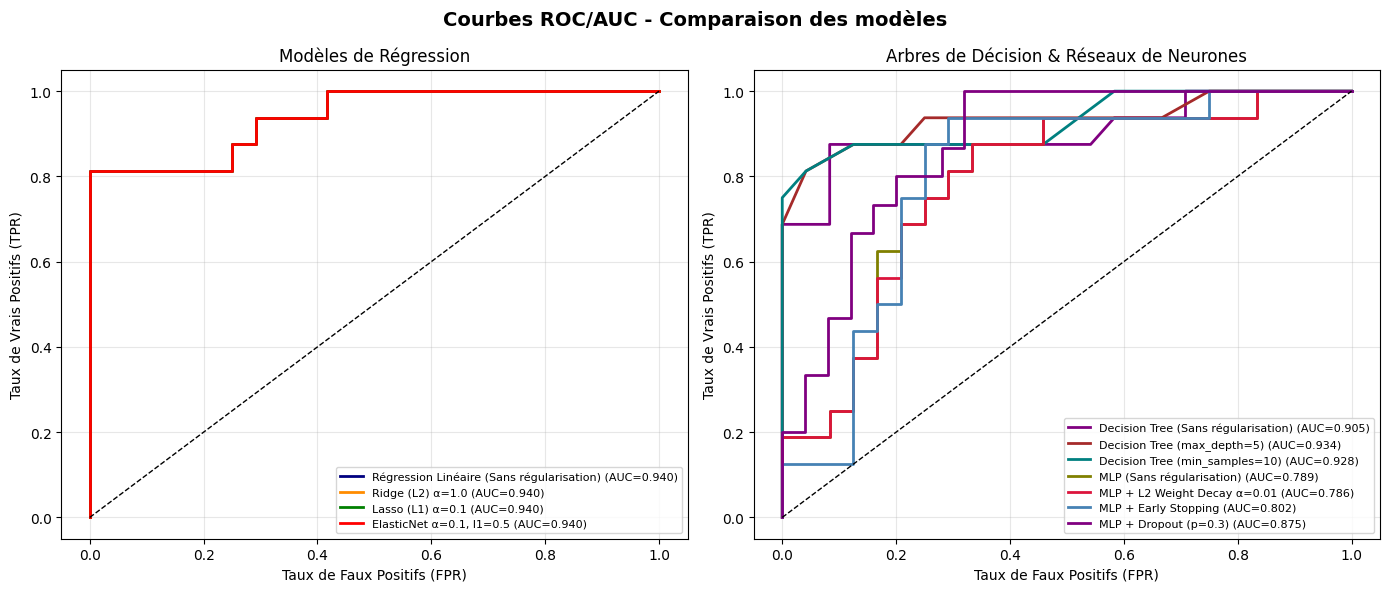

 Figure 1 sauvegardée : fig1_roc_curves.png


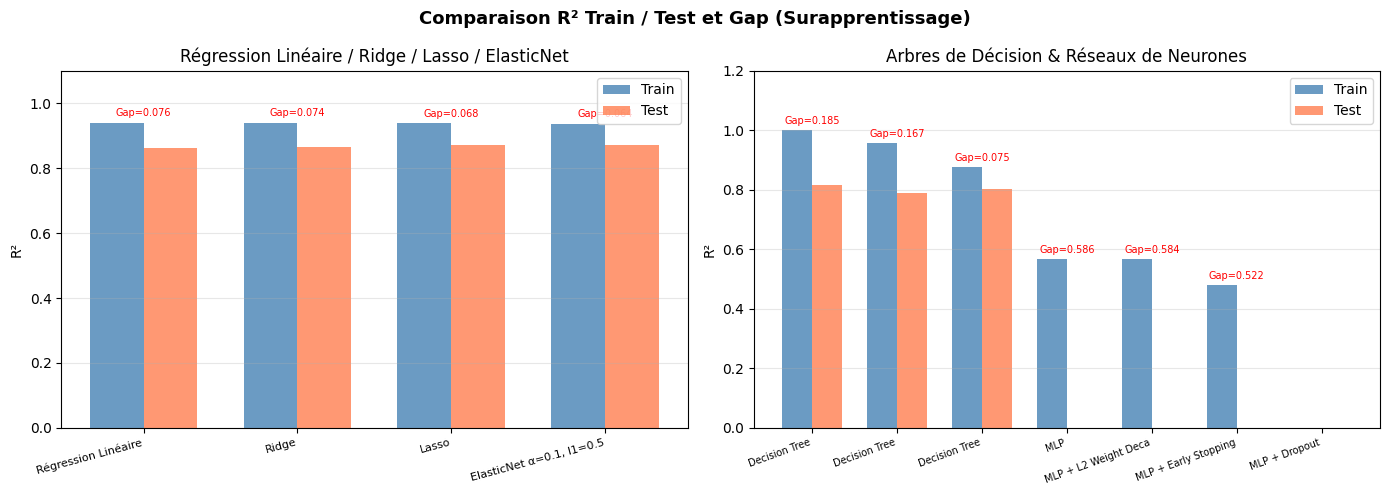

 Figure 2 sauvegardée : fig2_r2_comparison.png


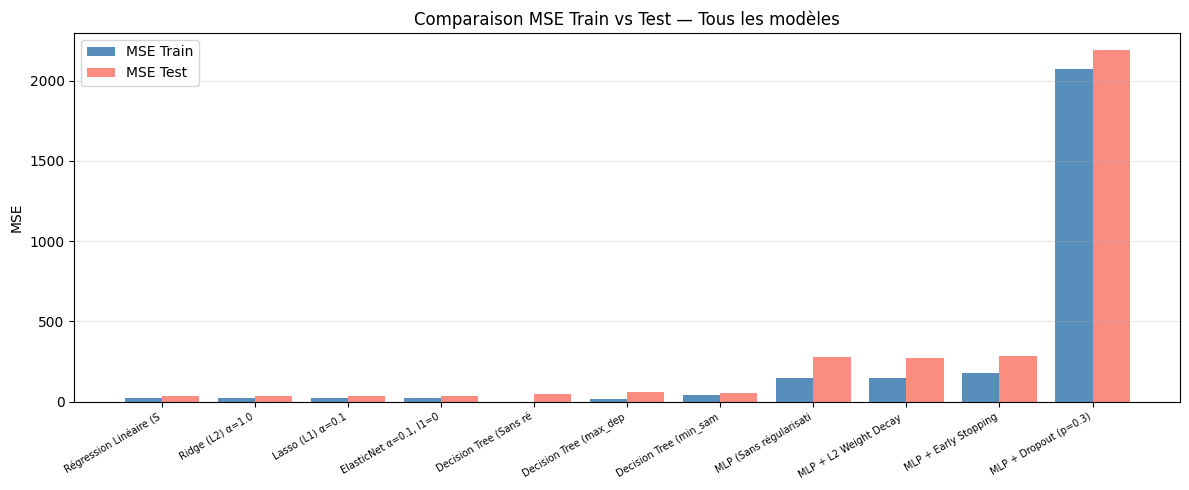

 Figure 3 sauvegardée : fig3_mse_comparison.png


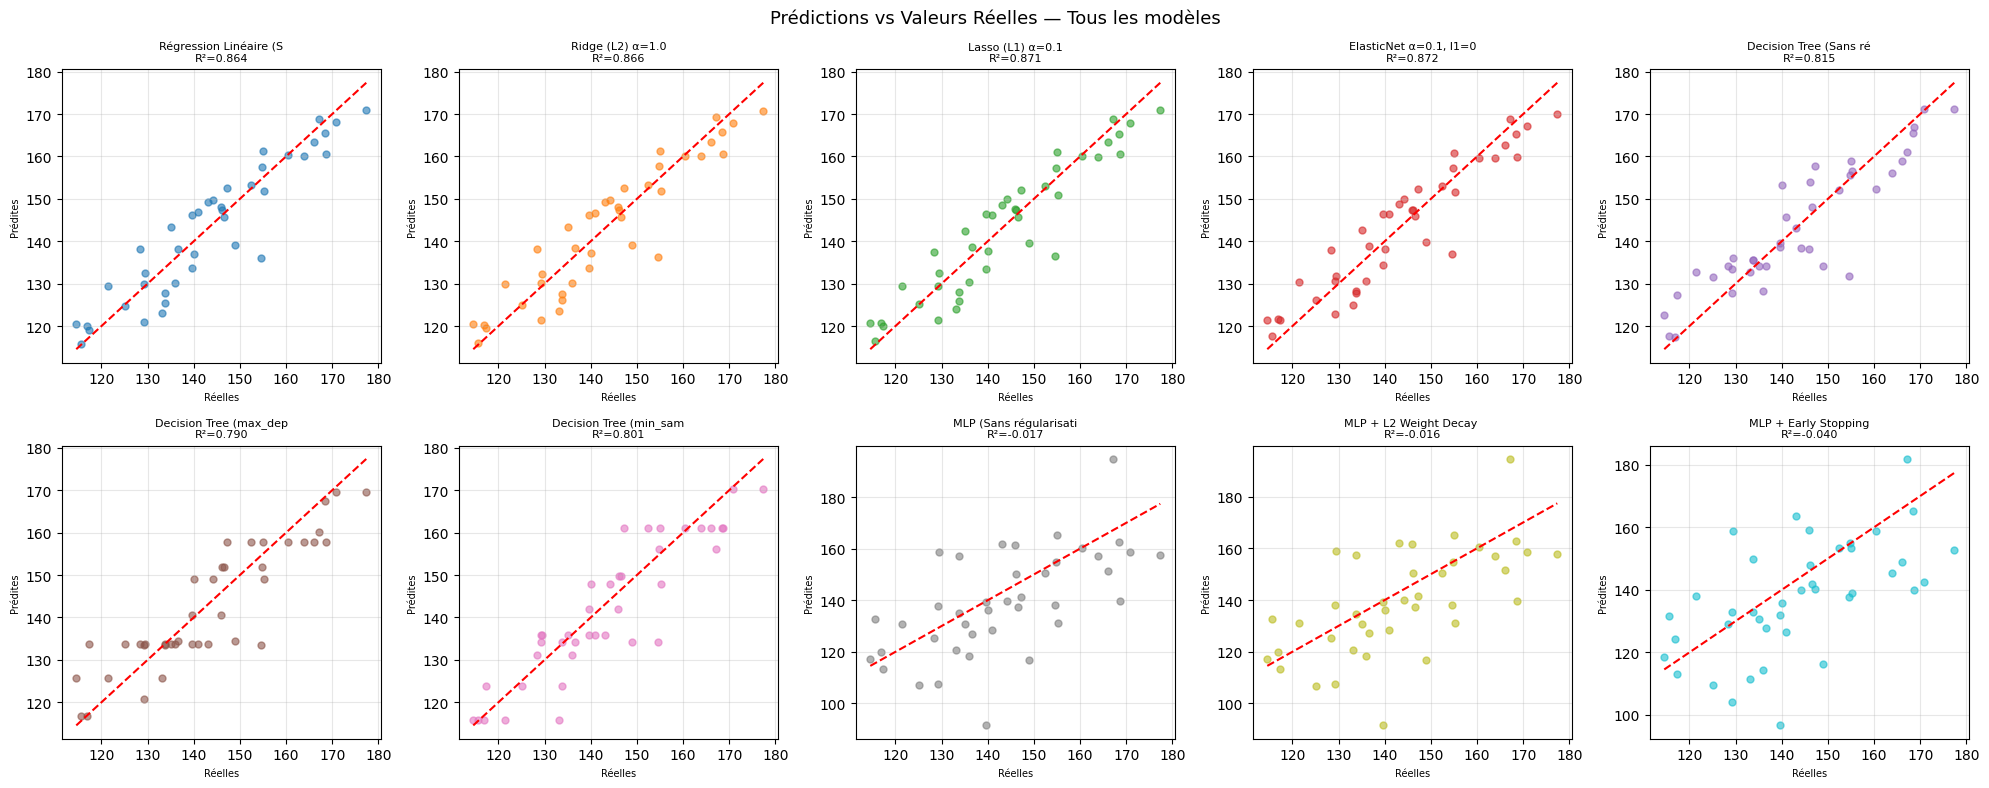

 Figure 4 sauvegardée : fig4_predictions.png


In [18]:
# Visualisations: ROC, R² comparaisons, MSE et prédictions vs réelles
all_results = results + tree_results + nn_results
# ── 7.1 Figure 1 : Courbes ROC/AUC - Modèles de régression ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Courbes ROC/AUC - Comparaison des modèles", fontsize=14, fontweight='bold')

# Régression models ROC
ax = axes[0]
ax.set_title("Modèles de Régression", fontsize=12)
colors = ['navy', 'darkorange', 'green', 'red']
for i, r in enumerate(results):
    lbl = r['Modèle'].replace('\n', ' ')
    ax.plot(r['fpr'], r['tpr'], color=colors[i % len(colors)], lw=2,
            label=f"{lbl} (AUC={r['AUC']:.3f})")
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR)")
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

# Tree + NN models ROC
ax = axes[1]
ax.set_title("Arbres de Décision & Réseaux de Neurones", fontsize=12)
colors2 = ['purple', 'brown', 'teal', 'olive', 'crimson', 'steelblue']
for i, r in enumerate(tree_results + nn_results):
    lbl = r['Modèle'].replace('\n', ' ')
    ax.plot(r['fpr'], r['tpr'], color=colors2[i % len(colors2)], lw=2,
            label=f"{lbl} (AUC={r['AUC']:.3f})")
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR)")
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 1 sauvegardée : fig1_roc_curves.png")

# ── 7.2 Figure 2 : Comparaison R² Train vs Test (Gap) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison R² Train / Test et Gap (Surapprentissage)", fontsize=13, fontweight='bold')

reg_df = pd.DataFrame(results)[["Modèle", "R² Train", "R² Test", "Gap R²"]].copy()
reg_df['Modèle'] = reg_df['Modèle'].apply(lambda x: x.split('(')[0].strip())

x_pos = np.arange(len(reg_df))
w = 0.35
ax = axes[0]
ax.bar(x_pos - w/2, reg_df['R² Train'], w, label='Train', color='steelblue', alpha=0.8)
ax.bar(x_pos + w/2, reg_df['R² Test'],  w, label='Test',  color='coral', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(reg_df['Modèle'], fontsize=8, rotation=15, ha='right')
ax.set_ylabel("R²")
ax.set_title("Régression Linéaire / Ridge / Lasso / ElasticNet")
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
for i, gap in enumerate(reg_df['Gap R²']):
    y_text = max(reg_df['R² Train'].iloc[i], reg_df['R² Test'].iloc[i]) + 0.02
    ax.annotate(f'Gap={gap:.3f}', xy=(i, y_text), ha='center', fontsize=7, color='red')

all_other = pd.DataFrame(tree_results + nn_results)[["Modèle", "R² Train", "R² Test", "Gap R²"]].copy()
all_other['Modèle'] = all_other['Modèle'].apply(lambda x: x.split('(')[0].strip()[:20])

x_pos2 = np.arange(len(all_other))
ax = axes[1]
ax.bar(x_pos2 - w/2, all_other['R² Train'], w, label='Train', color='steelblue', alpha=0.8)
ax.bar(x_pos2 + w/2, all_other['R² Test'],  w, label='Test',  color='coral', alpha=0.8)
ax.set_xticks(x_pos2)
ax.set_xticklabels(all_other['Modèle'], fontsize=7, rotation=20, ha='right')
ax.set_ylabel("R²")
ax.set_title("Arbres de Décision & Réseaux de Neurones")
ax.legend()
ax.set_ylim(0, 1.2)
ax.grid(axis='y', alpha=0.3)
for i, gap in enumerate(all_other['Gap R²']):
    y_text = max(all_other['R² Train'].iloc[i], all_other['R² Test'].iloc[i]) + 0.02
    ax.annotate(f'Gap={gap:.3f}', xy=(i, y_text), ha='center', fontsize=7, color='red')

plt.tight_layout()
plt.savefig("fig2_r2_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 2 sauvegardée : fig2_r2_comparison.png")

# ── 7.3 Figure 3 : MSE Train vs Test ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
all_df = pd.DataFrame(all_results)[["Modèle", "MSE Train", "MSE Test"]].copy()
all_df['Modèle'] = all_df['Modèle'].apply(lambda x: x[:22])
x_pos = np.arange(len(all_df))
ax.bar(x_pos - 0.2, all_df['MSE Train'], 0.4, label='MSE Train', color='steelblue', alpha=0.9)
ax.bar(x_pos + 0.2, all_df['MSE Test'],  0.4, label='MSE Test',  color='salmon', alpha=0.9)
ax.set_xticks(x_pos)
ax.set_xticklabels(all_df['Modèle'], fontsize=7, rotation=30, ha='right')
ax.set_ylabel("MSE")
ax.set_title("Comparaison MSE Train vs Test — Tous les modèles", fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("fig3_mse_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 3 sauvegardée : fig3_mse_comparison.png")

# ── 7.4 Figure 4 : Prédictions vs Valeurs Réelles ───────────────────────────
all_models_flat = list(models_reg.values()) + list(tree_models.values()) + list(nn_models.values())
all_names_flat  = list(models_reg.keys()) + list(tree_models.keys()) + list(nn_models.keys())

n_models = len(all_models_flat)
n_cols = 5
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
fig.suptitle("Prédictions vs Valeurs Réelles — Tous les modèles", fontsize=13)
axes = np.array(axes).reshape(-1)

for i, (name, model) in enumerate(zip(all_names_flat, all_models_flat)):
    try:
        y_pred = model.predict(X_test)
    except Exception:
        y_pred = np.full_like(y_test, np.nan, dtype=float)
    r2 = r2_score(y_test, y_pred) if not np.isnan(y_pred).all() else np.nan
    axes[i].scatter(y_test, y_pred, alpha=0.6, s=25, color=plt.cm.tab10(i % 10))
    mn, mx = y_test.min(), y_test.max()
    axes[i].plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    axes[i].set_title(f"{name.replace(chr(10),' ')[:22]}\nR²={r2:.3f}", fontsize=8)
    axes[i].set_xlabel("Réelles", fontsize=7)
    axes[i].set_ylabel("Prédites", fontsize=7)
    axes[i].grid(alpha=0.3)

# Hide extra subplot axes if any
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("fig4_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Figure 4 sauvegardée : fig4_predictions.png")